## I. POCA class

#### This class performs the PoCA reconstruction from a given csv file containing the hit information from the detector.
#### It is implicitly used by `precompute_poca.py`, which processes all the csv files in a given directory to pre-compute the PoCA-level information which is needed for training an nn model.
#### The user can, however, instantiate the POCA class with a specific csv file to do the reconstruction and visualize PoCA density projections. The POCA object can also be used as a diagnostic to visualize the voxelized input channels to the nn model.

In [127]:
from src.poca_reconstruction import POCA

#### Create an instance of the POCA class with the path to a specific csv file of hit information. The user has to define the VOI xyz limits, in mm, which must be compatible with the ground truth for training.

In [128]:
poca = POCA(
    "/nfs/user/zdaher/mst_nn/ironInConcrete/processed_root/scene_trial_0_processed.csv",
    xyz_min = (-600, -600, -2700),
    xyz_max = (600, 600, -1300),
    )

The `plot_poca_projections` method is used to plot projections of the PoCA density cloud.

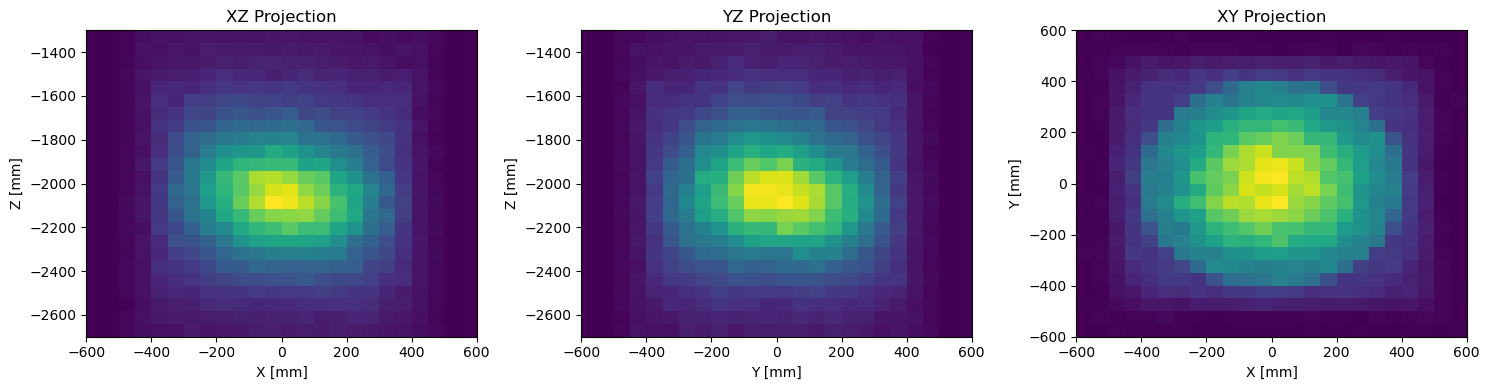

In [129]:
poca.plot_poca_projections(poca.poca, bins = 24)

The precomputed PoCA grids are obtained by executing `utils/precompute_poca.py`, in order to allow for faster training.  
The `MuonDataset` class is used for loading the training/validation/test datasets by iterating over the saved PoCA files. Below is an example usage of this dataset class.

## II. MuonDataset class

In [130]:
from src.data import MuonDataset

#### Define the path to saved PoCA files, and to to the corresponding ground truth maps.

In [131]:
poca_dir = '/nfs/user/zdaher/mst_nn/ironInConcrete/poca_voxels/' 
target_dir = '/nfs/user/zdaher/mst_nn/ironInConcrete/density_maps/'

In [132]:
dataset = MuonDataset(
    poca_dir=poca_dir,
    target_dir=target_dir,
    normalize_stats=None
)

print(f"Dataset size: {len(dataset)} samples") # number of samples found
print(f"Grid size D: {dataset.D}")
print(f"VOI min: {dataset.voi_min}, VOI max: {dataset.voi_max}")

Dataset size: 100 samples
Grid size D: 24
VOI min: [ -600.  -600. -2600.], VOI max: [  600.   600. -1400.]


#### Let's have a look at a sample

In [133]:
x, tgt, mask, name = dataset[0]

print("Input shape:", x.shape)          # (3, D, D, D)
print("Target shape:", tgt.shape)       # (1, D, D, D)
print("Mask shape:", mask.shape)        # (1, D, D, D)
print("Name:", name)

Input shape: (3, 24, 24, 24)
Target shape: (1, 24, 24, 24)
Mask shape: (1, 24, 24, 24)
Name: scene_trial_0


#### The first dimension of the input shape is the number of input channels to our nn.

### Visualizing a slice

#### Below is an example plot of XY slices (at mid-z) of the three channel grids.


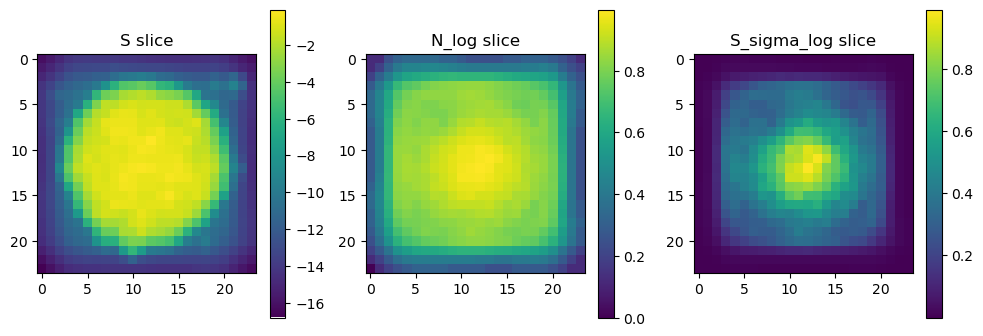

In [134]:
i = dataset.D // 2
i = 10
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,4))
plt.subplot(131); plt.title("S slice"); plt.imshow(np.log(x[0,:, :, i])); plt.colorbar();
plt.subplot(132); plt.title("N_log slice"); plt.imshow(x[1,:, :, i]); plt.colorbar()
plt.subplot(133); plt.title("S_sigma_log slice"); plt.imshow(x[2,:, :, i]); plt.colorbar()
plt.show()


### Using DataLoader
#### An instance of a DataLoader class is used during training to load batches of these datasets.

In [135]:
import torch
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4, # set to 0 if error appears
    pin_memory=True
)

for x, tgt, mask, names in loader:
    print("Batch X:", x.shape)     # (B, 3, D, D, D)
    print("Batch tgt:", tgt.shape) # (B, 1, D, D, D)
    print("Batch mask:", mask.shape)  # (B, 1, D, D, D)
    break


Batch X: torch.Size([4, 3, 24, 24, 24])
Batch tgt: torch.Size([4, 1, 24, 24, 24])
Batch mask: torch.Size([4, 1, 24, 24, 24])


#### Notice how DataLoader automatically converts the arrays to torch tensors.
#### Also note that first dimension of these loaded tensors is the batch size, i.e. number of samples loaded at a time.

## ProbUNet3D model

#### We now create an object model to train as an example.

In [136]:
from src.model import ProbUNet3D

model = ProbUNet3D(
    in_channels=3,  # S,N, S_sigma
    out_channels=2,  # mean mu, std log(sigma)
    base_features=16,
    depth=4
).cuda()

#### A single prediction of the model on an iteration of the DataLoader

In [137]:
x, tgt, mask, name = next(iter(loader))

x = x.cuda()
tgt = tgt.cuda()
mask = mask.cuda()

pred = model(x)

print("pred shape:", pred.shape)  # (B, 2, D, D, D)
mu = pred[:,0:1]
log_sigma = pred[:,1:2]

print("mu range:", mu.min().item(), mu.max().item())
print("log_sigma range:", log_sigma.min().item(), log_sigma.max().item())


pred shape: torch.Size([4, 2, 24, 24, 24])
mu range: -1.1494570970535278 1.7209835052490234
log_sigma range: -0.6585355401039124 1.5016050338745117


#### Below is an example training loop for a few epochs

In [139]:
import torch
from torch.utils.data import DataLoader

from src.data import MuonDataset
from src.model import ProbUNet3D, nll_loss_masked

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

data_path = "/nfs/user/zdaher/mst_nn/ironInConcrete/training_datasets/"

train_dataset = MuonDataset(
    poca_dir   = f"{data_path}/train/poca_voxels",
    target_dir = f"{data_path}/train/density_maps",
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=4, # set to 0 if issues occur
    pin_memory=False,
)

# Model + Optimizer
model = ProbUNet3D(
    in_channels=3,
    out_channels=2,
    base_features=16,
    depth=4
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

# example of a few training epochs

n_epochs = 2

for epoch in range(1, n_epochs + 1):

    model.train()
    total_loss = 0
    n_batches = 0

    print(f"\nEpoch {epoch}/{n_epochs}")

    for batch_idx, (x, tgt, mask, name) in enumerate(train_loader):
        
        x    = x.to(device)
        tgt  = tgt.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()

        pred = model(x)

        loss = nll_loss_masked(pred, tgt, mask)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

        if batch_idx % 5 == 0:
            print(f"  batch {batch_idx:3d} | loss={loss.item():.4f}")

    print(f"Epoch {epoch} avg loss = {total_loss / n_batches:.4f}")


Device: cuda

Epoch 1/2
  batch   0 | loss=0.8000
  batch   5 | loss=0.5046
  batch  10 | loss=0.4072
  batch  15 | loss=0.3282
  batch  20 | loss=0.2544
  batch  25 | loss=0.1917
  batch  30 | loss=0.1332
  batch  35 | loss=0.0583
  batch  40 | loss=0.0015
  batch  45 | loss=-0.0615
  batch  50 | loss=-0.1183
  batch  55 | loss=-0.1721
  batch  60 | loss=-0.2262
  batch  65 | loss=-0.2829
  batch  70 | loss=-0.3402
  batch  75 | loss=-0.3947
Epoch 1 avg loss = 0.0332

Epoch 2/2
  batch   0 | loss=-0.4563
  batch   5 | loss=-0.5125
  batch  10 | loss=-0.5740
  batch  15 | loss=-0.5241
  batch  20 | loss=-0.6471
  batch  25 | loss=-0.7172
  batch  30 | loss=-0.7843
  batch  35 | loss=-0.8404
  batch  40 | loss=-0.9106
  batch  45 | loss=-0.8659
  batch  50 | loss=-1.0041
  batch  55 | loss=-1.0653
  batch  60 | loss=-1.1423
  batch  65 | loss=-1.2072
  batch  70 | loss=-1.1899
  batch  75 | loss=-1.3006
Epoch 2 avg loss = -0.8865


#### While it is possible to train the model in a jupyter notebook, we will train with running a script (`train/train.py`) in terminal mode for the sake of speed. 

#### Inspecting the prediction of the last update step

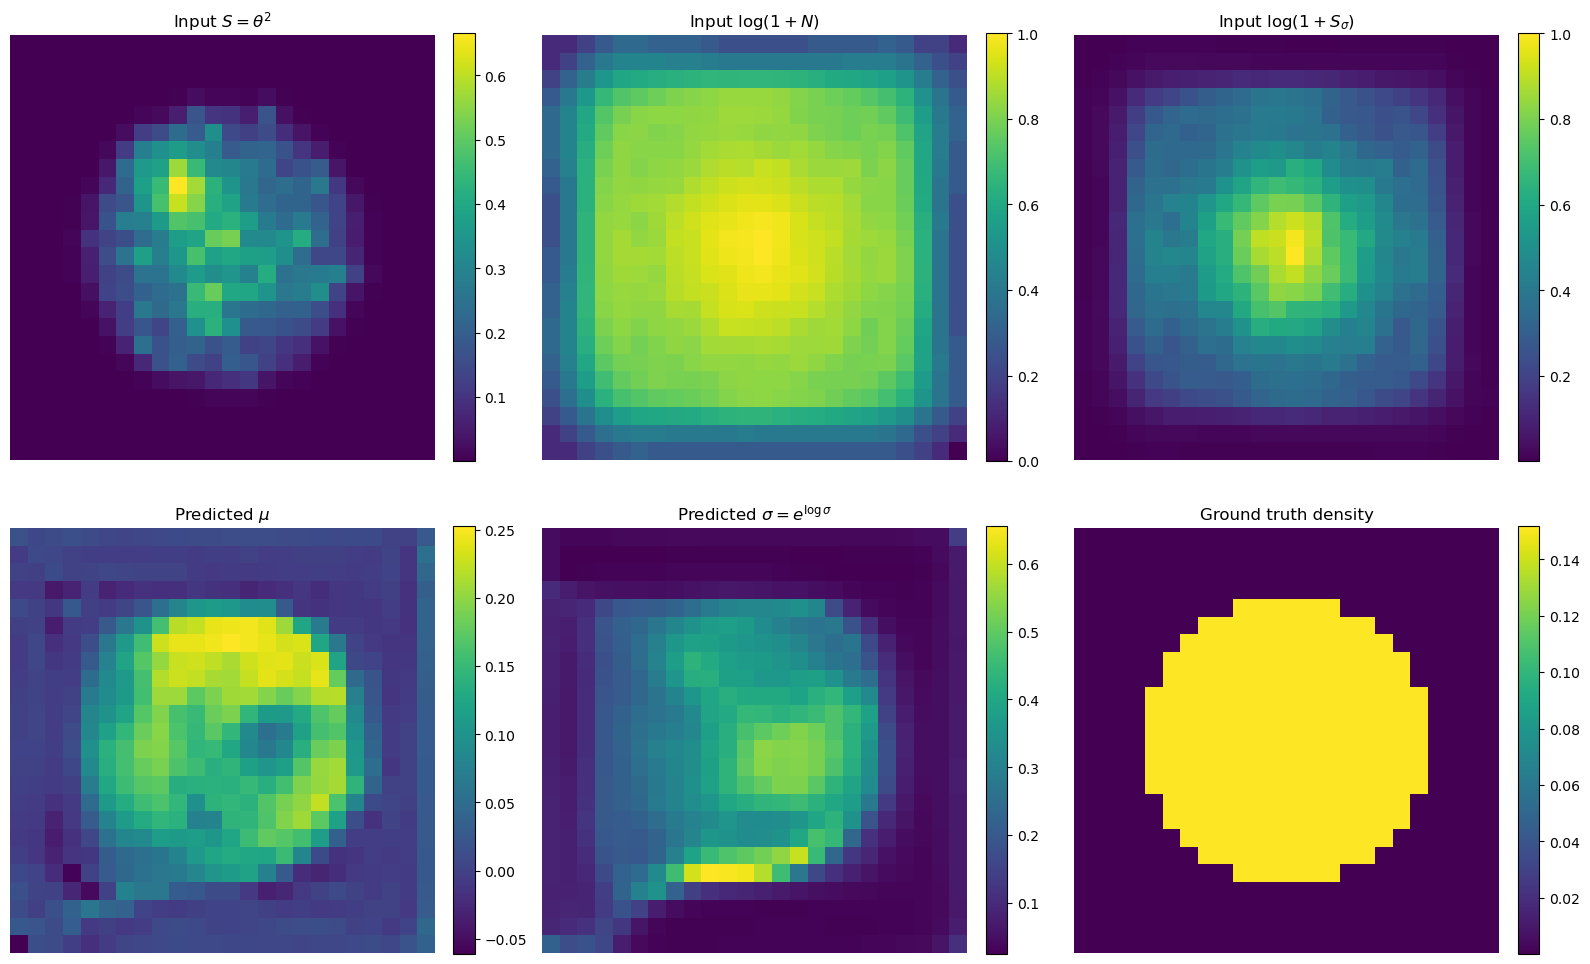

In [141]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ----------------------------------------
# Extract fields from last forward step
# ----------------------------------------
S           = x[0,0].detach().cpu().numpy()
N_log       = x[0,1].detach().cpu().numpy()
S_sigma_log = x[0,2].detach().cpu().numpy()

gt          = tgt[0,0].detach().cpu().numpy()

mu          = pred[0,0].detach().cpu().numpy()
sigma       = torch.exp(pred[0,1]).detach().cpu().numpy()

mask_np     = mask[0,0].detach().cpu().numpy()

# Mid-slice
D = mu.shape[0]
z = D//2

# ----------------------------------------
# Plot
# ----------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(16, 10))

def show(ax, data, title):
    im = ax.imshow(data, cmap='viridis')
    ax.set_title(title)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Inputs
show(axs[0,0], S[:, : ,z], r"Input $S = \theta^2$")
show(axs[0,1], N_log[:, : ,z], r"Input $\log(1+N)$")
show(axs[0,2], S_sigma_log[:, : ,z], r"Input $\log(1+S_\sigma)$")

# Outputs
show(axs[1,0], mu[:, : ,z], r"Predicted $\mu$")
show(axs[1,1], sigma[:, : ,z], r"Predicted $\sigma = e^{\log \sigma}$")

# Ground truth
show(axs[1,2], gt[:, : ,z], "Ground truth density")

plt.tight_layout()
plt.show()



#### For proper training, a common practice is to split the dataset into separate training/validation/testing datasets in 80/10/10 fractions. The model is validated against the validation dataset during training but without updating model parameters to detect any overfitting. The testing dataset is evaluated after training in evaluation mode (model.eval()).

#### The script `train/split_dataset.py` splits our full dataset and stores the different datasets in separate folders.

#### Below, we show an example of loading a pre-trained model, whose final state is saved in `train/train_outputs`. The model was trained on a split dataset found in `train/datasets_boneInConcrete`.

#### The loaded model will be evaluated with a test dataset `train/datasets_boneInConcrete/test/`

In [142]:
from src.model import ProbUNet3D 

device = "cuda" if torch.cuda.is_available() else "cpu"

ckpt_path = "/home/ucl/cp3/zdaher/MST_NN/train/train_outputs/best_model.pt"
ckpt = torch.load(ckpt_path, map_location=device)

model = ProbUNet3D(in_channels=3, out_channels=2, base_features=16).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("Loaded model from:", ckpt_path)

Loaded model from: /home/ucl/cp3/zdaher/MST_NN/train/train_outputs/best_model.pt


/scratch/zdaher/64603689/ipykernel_284712/3984040058.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


In [143]:
from src.data import MuonDataset
poca_dir   = "/nfs/user/zdaher/mst_nn/ironInConcrete/training_datasets/test/poca_voxels/"
target_dir = "/nfs/user/zdaher/mst_nn/ironInConcrete/training_datasets/test/density_maps"

val_ds = MuonDataset(poca_dir, target_dir)
val_dl = DataLoader(val_ds, batch_size=2, num_workers=0)

In [144]:
x, y, mask, name = next(iter(val_dl))
x = x.to(device)
y = y.to(device)
mask = mask.to(device)

with torch.no_grad():
    pred = model(x)

mu = pred[:, 0]
sigma = torch.exp(pred[:, 1])

print("Shapes:")
print("mu:", mu.shape)
print("sigma:", sigma.shape)
print("target:", y.shape)

Shapes:
mu: torch.Size([2, 24, 24, 24])
sigma: torch.Size([2, 24, 24, 24])
target: torch.Size([2, 1, 24, 24, 24])


In [145]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_slices(mu, sigma, target, batch_idx=0, axis="z", n_slices=4):
    """
    mu, sigma, target: tensors of shape [B, 1, D, D, D] or [B, D, D, D]
    """

    # --- Select sample ---
    mu_b     = mu[batch_idx].detach().cpu().squeeze()
    sigma_b  = sigma[batch_idx].detach().cpu().squeeze()
    target_b = target[batch_idx].detach().cpu().squeeze()

    if mu_b.ndim != 3:
        raise ValueError(f"Expected (D,D,D), got {mu_b.shape}")

    D = mu_b.shape[0]

    # --- Choose slice indices ---
    idxs = np.linspace(0, D-1, n_slices).astype(int)

    # --- Compute global vmin/vmax for each channel ---
    mu_min,     mu_max     = float(mu_b.min()),     float(mu_b.max())
    sig_min,    sig_max    = float(sigma_b.min()),  float(sigma_b.max())
    tgt_min,    tgt_max    = float(target_b.min()), float(target_b.max())

    # --- Prepare figure ---
    fig, axs = plt.subplots(n_slices, 3, figsize=(13, 4*n_slices))

    for row, idx in enumerate(idxs):

        # --- Extract slice ---
        if axis == "z":
            s_mu     = mu_b[:, :, idx]
            s_sigma  = sigma_b[:, :, idx]
            s_target = target_b[:, :, idx]
        elif axis == "y":
            s_mu     = mu_b[:, idx, :]
            s_sigma  = sigma_b[:, idx, :]
            s_target = target_b[:, idx, :]
        elif axis == "x":
            s_mu     = mu_b[idx, :, :]
            s_sigma  = sigma_b[idx, :, :]
            s_target = target_b[idx, :, :]
        else:
            raise ValueError("axis must be x, y, or z")

        # --- μ ---
        im0 = axs[row, 0].imshow(s_mu.numpy(), cmap="viridis",
                                 vmin=mu_min, vmax=mu_max)
        axs[row, 0].set_title(f"μ (slice {idx})")
        fig.colorbar(im0, ax=axs[row, 0], fraction=0.046, pad=0.04)

        # --- σ ---
        im1 = axs[row, 1].imshow(s_sigma.numpy(), cmap="viridis",
                                 vmin=sig_min, vmax=sig_max)
        axs[row, 1].set_title("σ")
        fig.colorbar(im1, ax=axs[row, 1], fraction=0.046, pad=0.04)

        # --- target ---
        im2 = axs[row, 2].imshow(s_target.numpy(), cmap="viridis",
                                 vmin=tgt_min, vmax=tgt_max)
        axs[row, 2].set_title("target")
        fig.colorbar(im2, ax=axs[row, 2], fraction=0.046, pad=0.04)

        for col in range(3):
            axs[row, col].axis("off")

    plt.tight_layout()
    plt.show()


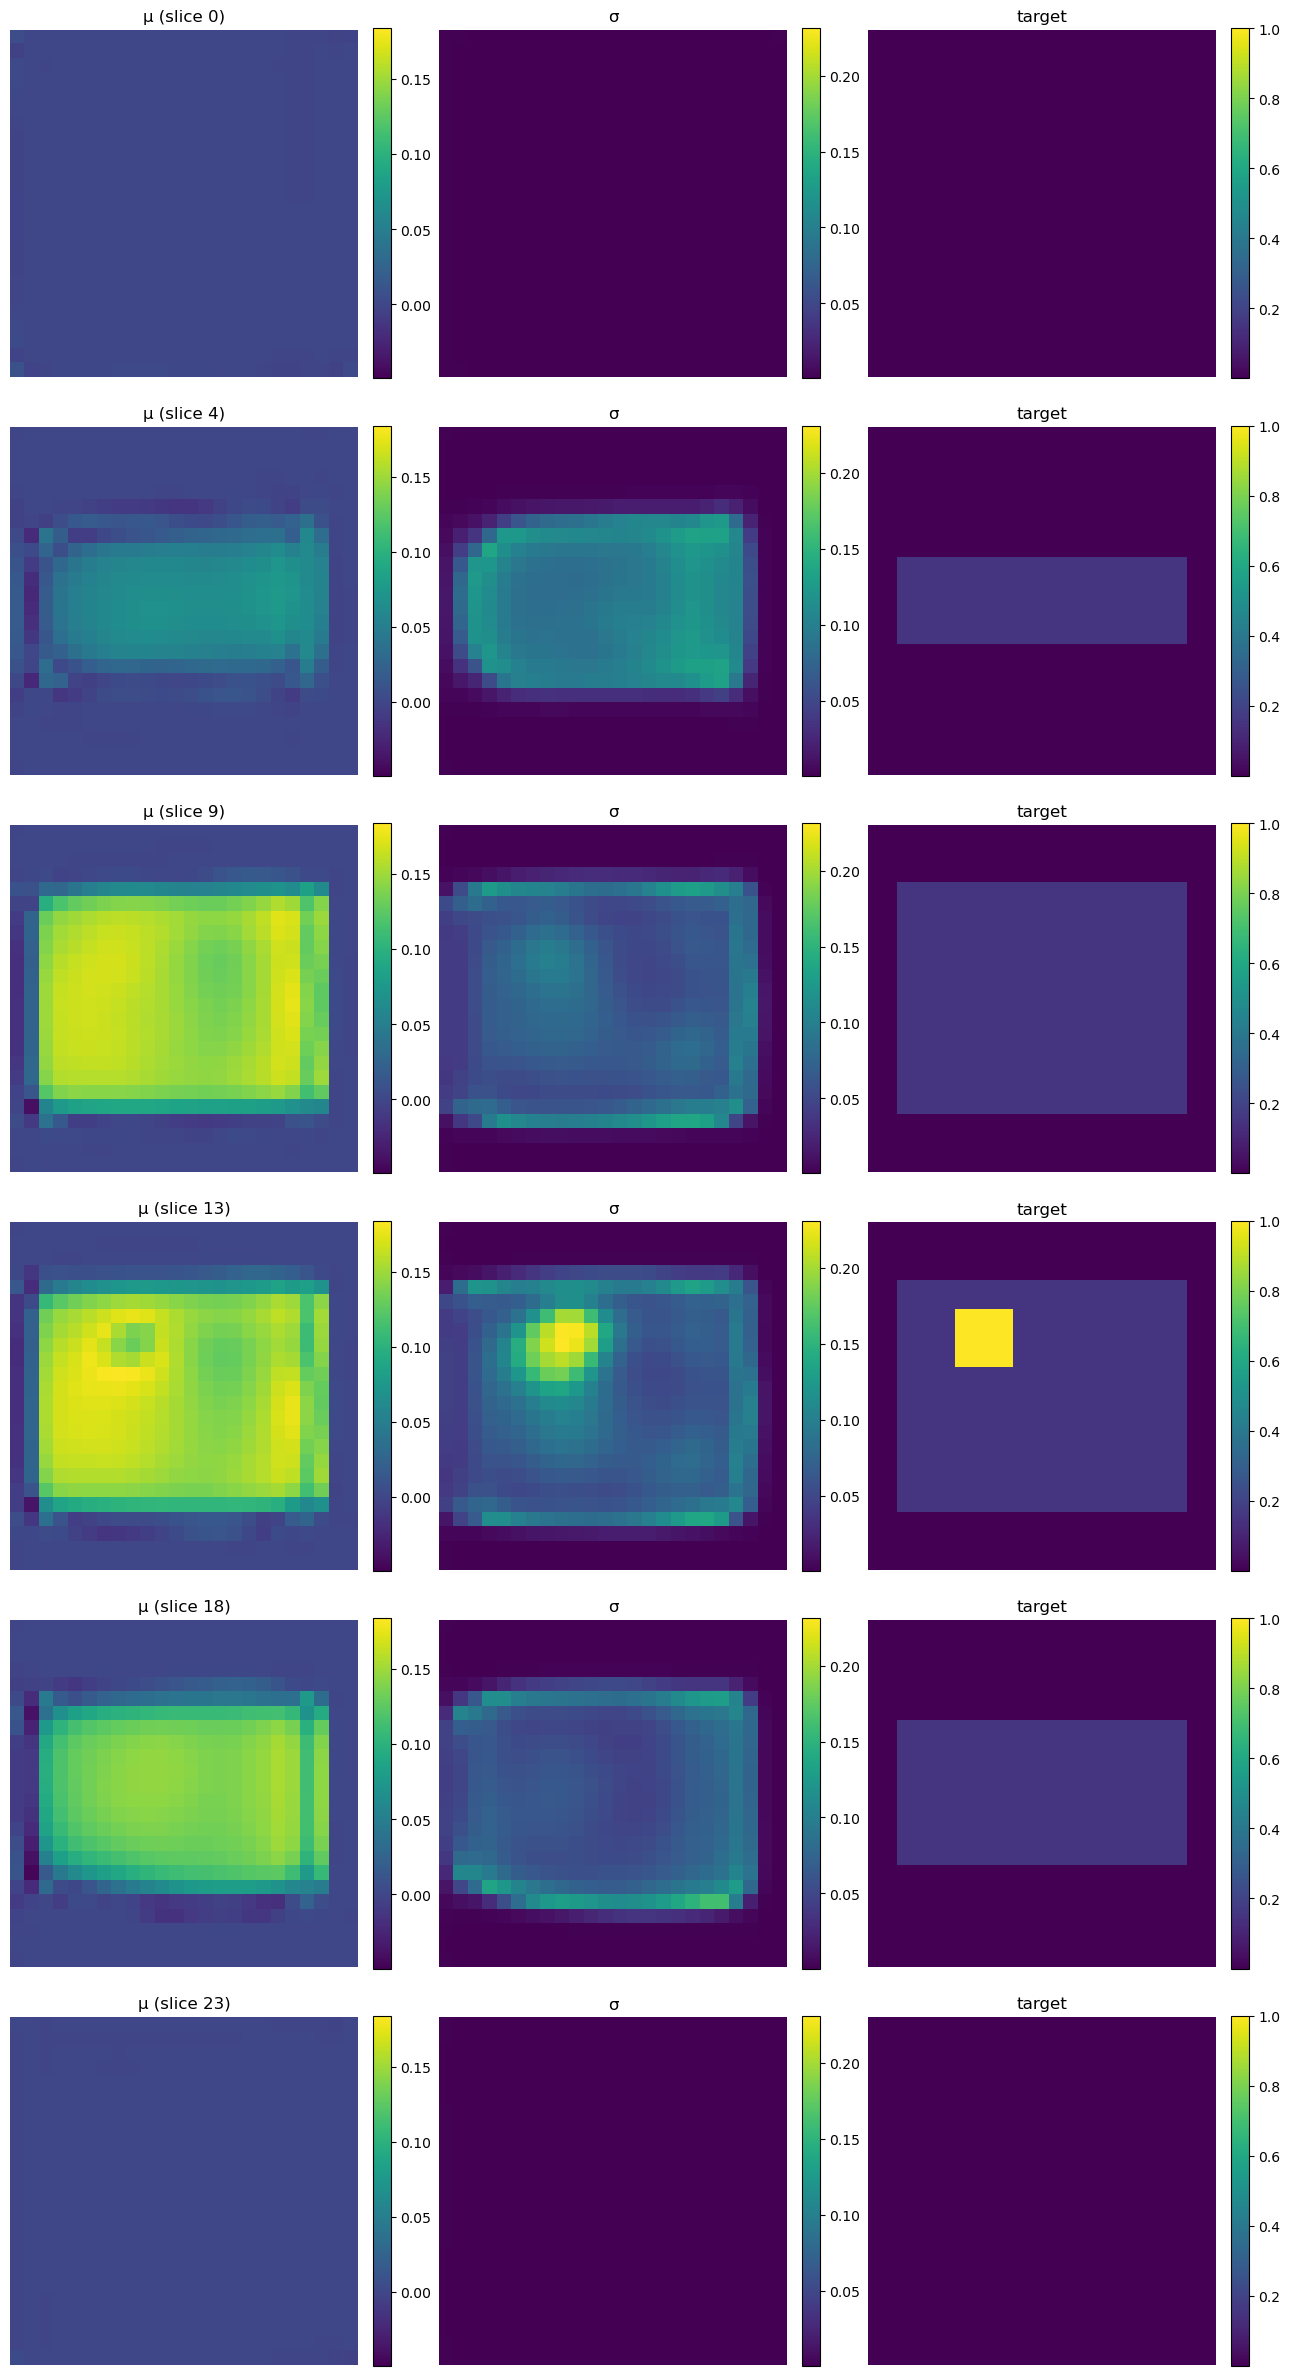

In [146]:
plot_slices(mu, sigma, y, axis="x", n_slices=6, batch_idx=1)

/scratch/zdaher/64603689/ipykernel_284712/4253755884.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  history = torch.load("train/train_outputs/loss_history.pt")


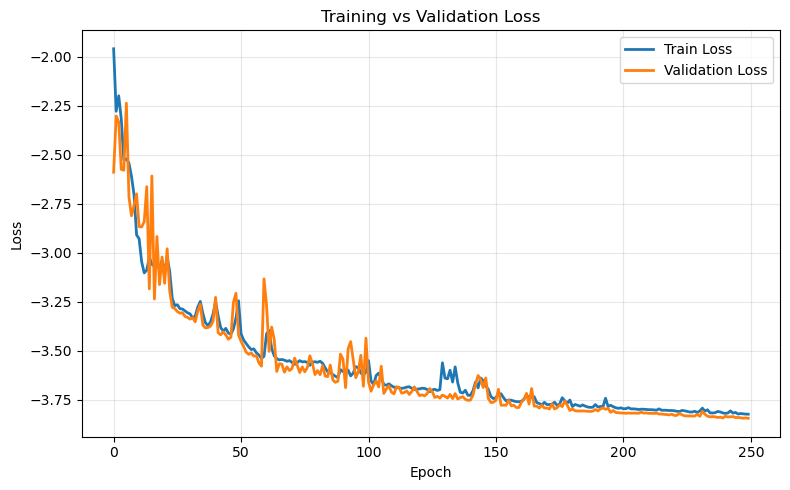

In [147]:
import torch
import matplotlib.pyplot as plt

history = torch.load("train/train_outputs/loss_history.pt")

train_losses = history["train_losses"][50:]
val_losses   = history["val_losses"][50:]

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Loaded volume: (24, 24, 24)
min: 0.0176 max: 10000000.0


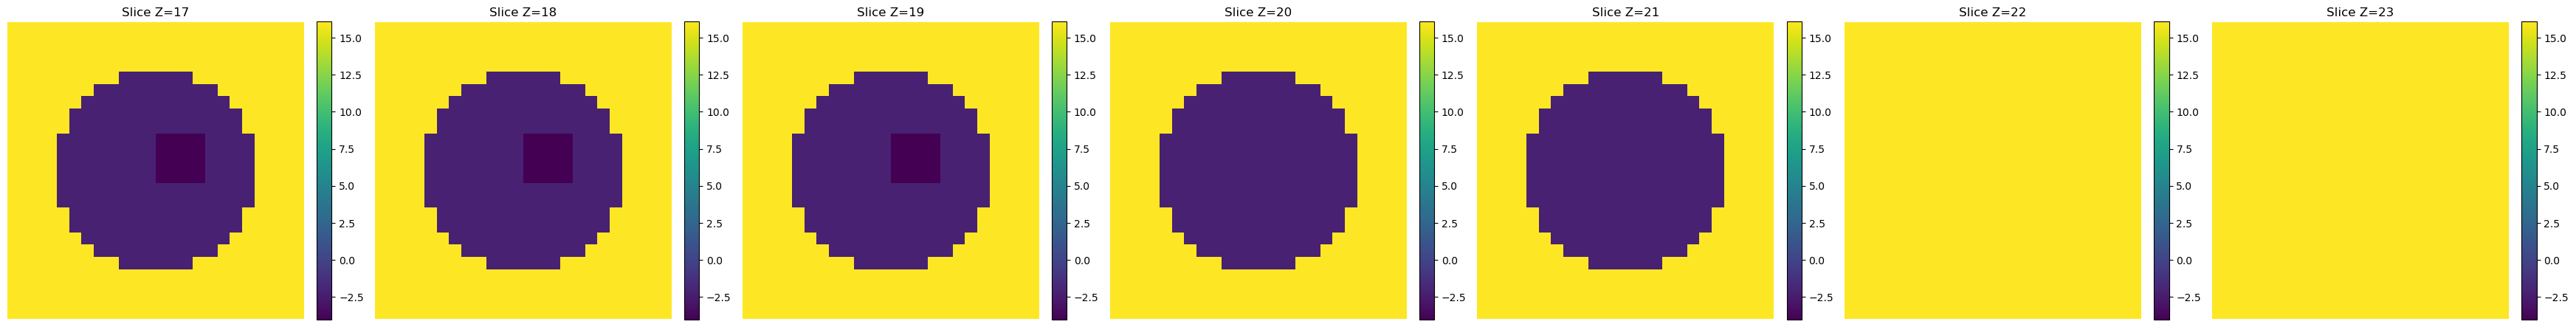

Volume min: 0.0176


In [148]:
import numpy as np
import matplotlib.pyplot as plt

# path to ground voxelization to inspect
path = "/nfs/user/zdaher/mst_nn/ironInConcrete/density_maps/scene_trial_4_X0.npy"

vol = np.load(path)         # shape: (D, D, D)
D = vol.shape[0]

print("Loaded volume:", vol.shape)
print("min:", vol.min(), "max:", vol.max())

# choose slices to visualize
z_slices = np.arange(17, 24, 1)

# Compute log-volume and global min/max for consistent scale
log_vol = np.log(vol + 1e-9)      # avoid log(0)
vmin = np.nanmin(log_vol)
vmax = np.nanmax(log_vol)

n = len(z_slices)
fig, axs = plt.subplots(1, n, figsize=(5*n, 5))

for i, z in enumerate(z_slices):
    im = axs[i].imshow(
        log_vol[:, :, z],
        cmap="viridis",
        vmin=vmin,
        vmax=vmax
    )
    axs[i].set_title(f"Slice Z={z}")
    axs[i].axis("off")

    # Add colorbar for each subplot
    fig.colorbar(im, ax=axs[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("Volume min:", vol.min())
